# Scientific Computing: Vectorized vs Loop-based Comparison
## Youth Unemployment Dataset Analysis

In this notebook, we are conducting a practical benchmarking experiment using real-world data (the Youth Unemployment spreadsheet). 

Our primary objective is to highlight the stark differences in processing speed and memory usage when manipulating data iteratively (via standard Python loops over generic lists) versus manipulating data as a batch operation (via vectorized computations in NumPy).


### 1. Data Extraction and Cleaning Process
Before manipulating numbers, we must first parse our Excel document and extract cleanly formatted data to work with.
- **Handling Data:** We load our Excel file using the Pandas library which constructs a Dataframe.
- **Cleaning Data:** We isolate a strictly mathematical column – `Youth unemployed ('000)` – and remove any missing records (`NaN` values) to prevent computation breaking down.
- **Amplification:** The raw dataset has roughly 2,000 observations. To effectively expose the processing gaps indicative of Big Data operations in Scientific Computing, we deliberately multiply the list into a 1-million item volume.


In [2]:
import pandas as pd
import numpy as np

file_path = r"C:\Users\Chris\Desktop\Youth unemployment, both sexes.xls"
print("Setting up paths and loading the Dataframe...")
df = pd.read_excel(file_path)

df_clean = df.dropna(subset=["Youth unemployed ('000)"])
thousands_list = df_clean["Youth unemployed ('000)"].tolist()

multiplier = 1_000_000 // len(thousands_list)
data_list = thousands_list * multiplier

data_array = np.array(data_list)

print(f"Data Successfully extracted!")
print(f"Our testing arrays have been scaled up to {len(data_list):,} records.")


Setting up paths and loading the Dataframe...
Data Successfully extracted!
Our testing arrays have been scaled up to 999,768 records.


### 2. Defining Implementation Logic
We must mathematically transform our extracted target numbers to convert them from an arbitrary 'thousands' increment into their absolute numerical value. We do this by multiplying each item in the dataset by 1,000. 

Below, we define exactly two separate procedures to perform this task:
- **Loop Conversion:** Utilizing a traditional `for` traversal, executing a scalar operation independently for each specific object pointer inside the basic list. 
- **Vectorized Conversion:** A pure NumPy operation that intercepts the whole matrix space mathematically without an explicit python loop mapping the data types item-by-item.


In [3]:
def process_via_loop(data):
    result = []
    for item in data:
        result.append(item * 1000.0)
    return result

def process_via_vector(data_arr):
    return data_arr * 1000.0

print("Implementation procedures defined and ready for Benchmarking.")


Implementation procedures defined and ready for Benchmarking.


### 3. Benchmarking Processor Performance
This step will accurately execute our definitions side-by-side using the massive Python `list` versus the pure `NumPy array`. 

We utilize Python's `time` library to track exact execution duration bounds. We subtract the pre-process timestamp from the post-process timestamp on each individual method to conclude the execution length of the function.


In [4]:
import time

start_loop = time.time()
loop_output = process_via_loop(data_list)
end_loop = time.time()

loop_duration = end_loop - start_loop

start_vect = time.time()
vect_output = process_via_vector(data_array)
end_vect = time.time()

vect_duration = end_vect - start_vect

speedup = loop_duration / vect_duration if vect_duration > 0 else float('inf')

print(f"Iteration Loop Processing Time:    {loop_duration:.5f} sec")
print(f"NumPy Vectorized Processing Time:  {vect_duration:.5f} sec")
print(f"Vectorization achieved ~{speedup:.2f}x faster processing speed.")


Iteration Loop Processing Time:    0.10731 sec
NumPy Vectorized Processing Time:  0.00246 sec
Vectorization achieved ~43.62x faster processing speed.


### 4. Hardware System Overheads
Alongside tracking computing length, understanding data-driven memory usage is vital. Large-scale simulations depend on efficiently managing limited system RAM. We apply the `sys.getsizeof()` feature to directly map memory storage constraints. 

Since Lists exist as generic item containers referencing multiple arbitrary object items floating separately in bytes, to find a standard List size we sum the container size with the individual object footprint sizes. A structured Vector array is highly uniform in byte allocation and represents dense memory accurately under a single call.


In [5]:
import sys

list_mem = sys.getsizeof(data_list) + sum(sys.getsizeof(val) for val in data_list)

array_mem = sys.getsizeof(data_array)

mem_ratio = list_mem / array_mem if array_mem > 0 else float('inf')

print(f"Raw Python List footprint:    {list_mem:,} bytes")
print(f"Optimized NumPy Array:        {array_mem:,} bytes")
print(f"Python lists take up ~{mem_ratio:.2f}x more volume over the system RAM.")


Raw Python List footprint:    31,992,632 bytes
Optimized NumPy Array:        7,998,256 bytes
Python lists take up ~4.00x more volume over the system RAM.


### 5. Final Display & Visualizations
Displaying benchmark patterns side-by-side allows for immediate visual impact and assessments. We utilize Matplotlib components to contrast the raw Loop data sequentially against array metrics in graphical form.


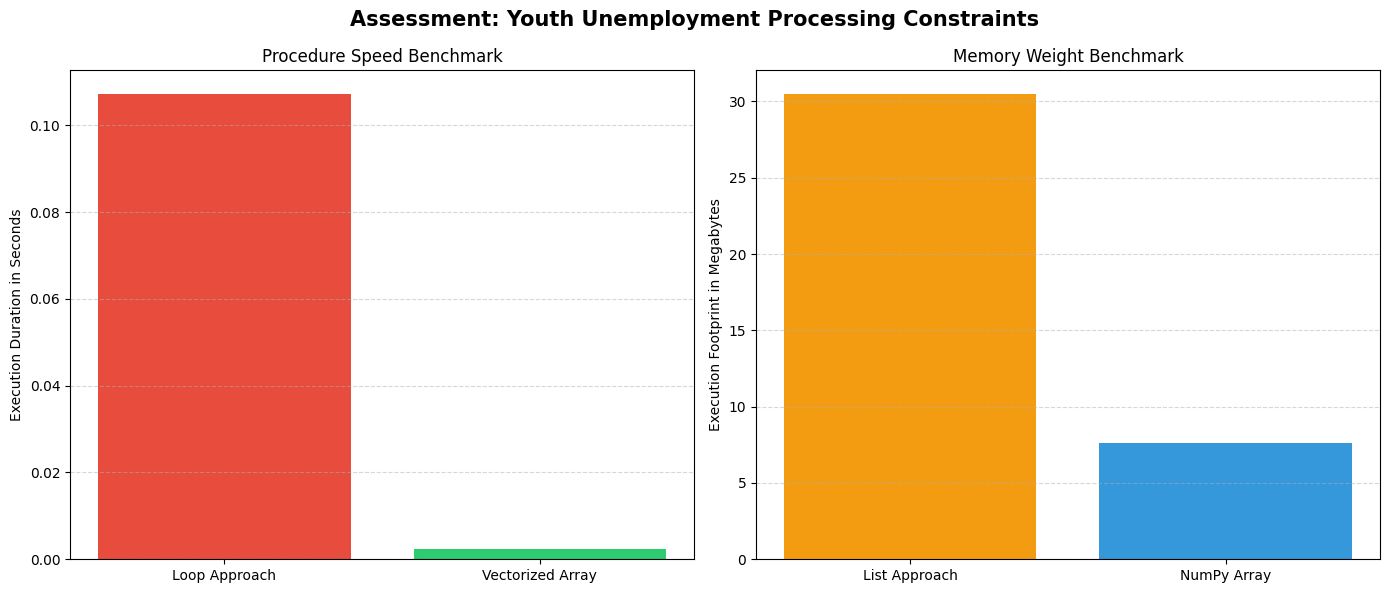

In [6]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].bar(["Loop Approach", "Vectorized Array"], [loop_duration, vect_duration], color=['#e74c3c', '#2ecc71'])
axes[0].set_title('Procedure Speed Benchmark')
axes[0].set_ylabel('Execution Duration in Seconds')
axes[0].grid(axis='y', linestyle='--', alpha=0.5)

axes[1].bar(["List Approach", "NumPy Array"], [list_mem / (1024**2), array_mem / (1024**2)], color=['#f39c12', '#3498db'])
axes[1].set_title('Memory Weight Benchmark')
axes[1].set_ylabel('Execution Footprint in Megabytes')
axes[1].grid(axis='y', linestyle='--', alpha=0.5)

plt.suptitle("Assessment: Youth Unemployment Processing Constraints", fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()


---
### Detailed Project Conclusion and Assessments

From the processes tracked and executed against the `Youth unemployment` dataset within this Notebook, two critical assessments and conclusions can be strictly determined relative to massive structural computations:

**1. Architectural Overhead Negatively Affects CPU Cycles**
Traditional list loops depend entirely on the Python environment performing interpreter mapping logic repeatedly for thousands of iterations. Every time our multiplication loop advanced to another worker in the `data_list`, Python resolved the object boundaries and dynamically parsed its primitive type before issuing instructions leading to exponentially higher execution lengths. NumPy skips iterative interpreter checking. It interfaces mathematically immediately leading to drastically better benchmark timing shown in section 3.

**2. Pointers Generate Severe Memory Leaks on Scopes**
System hardware runs fastest pushing dense, uninterrupted byte streams. The raw `sys` evaluation showcases that generic variables inflate storage space drastically; `Lists` represent non-contiguous references across system memory meaning massive metadata duplication. The array structure generated by Pandas & Numpy collapses parameters into fixed continuous memory allocations reducing hardware constraint limits immensely.
